## 1. Data Acquisition and Preprocessing

### Objective

Construct two datasets:

- **Genome-wide dataset (chr20–22)** for GRM construction and PCA.
- **chr22-only dataset** for association testing.

In [ ]:
!plink --version

In [ ]:
%%bash
# 1.1 Convert VCF to PLINK format

set -euo pipefail

mkdir -p data_preprocessed

# 1) Convert each chromosome VCF (chr20–22) to PLINK bed/bim/fam
for chr in {20..22}; do
  echo "Converting chr${chr} VCF to PLINK..."
  plink --vcf data/ALL.chr${chr}.phase3_shapeit2_mvncall_integrated_v5a.20130502.genotypes.vcf.gz \
        --make-bed \
        --biallelic-only strict list \
        --snps-only just-acgt \
        --out data_preprocessed/tmp.chr${chr}
done

# Rename variant IDs in each .bim to ensure uniqueness (CHR:BP:A1:A2)
for chr in 20 21 22; do
  awk '{ $2 = $1 ":" $4 ":" $5 ":" $6; print }' data_preprocessed/tmp.chr${chr}.bim > data_preprocessed/tmp.chr${chr}.bim.tmp
  mv data_preprocessed/tmp.chr${chr}.bim.tmp data_preprocessed/tmp.chr${chr}.bim
done

# 2) Build genome-wide dataset (chr20–22)
#    Use chr20 as base and merge chr21–22.
merge_list=data_preprocessed/merge_list.txt
: > "${merge_list}"
for chr in {21..22}; do
  echo "data_preprocessed/tmp.chr${chr}.bed data_preprocessed/tmp.chr${chr}.bim data_preprocessed/tmp.chr${chr}.fam" >> "${merge_list}"
done

plink --bfile data_preprocessed/tmp.chr20 \
      --merge-list "${merge_list}" \
      --make-bed \
      --out data_preprocessed/genome_raw

# 3) Extract chr22-only dataset from genome-wide set
plink --bfile data_preprocessed/genome_raw \
      --chr 22 \
      --make-bed \
      --out data_preprocessed/chr22_raw


In [ ]:
# 1.2 Quality Control

In [ ]:
%%bash
# 1.2 Quality Control

set -euo pipefail

mkdir -p data_preprocessed

# Genome-wide QC on merged chr20–22 dataset
plink --bfile data_preprocessed/genome_raw \
      --maf 0.05 \
      --geno 0.02 \
      --hwe 1e-6 \
      --make-bed \
      --out data_preprocessed/genome_qc

# QC on chr22-only dataset
plink --bfile data_preprocessed/chr22_raw \
      --maf 0.05 \
      --geno 0.02 \
      --make-bed \
      --out data_preprocessed/chr22_qc


In [ ]:
%%bash
# 1.3 LD Pruning for PCA and GRM Stability

set -euo pipefail

# Identify LD-independent SNPs (window 50, step 5, r² 0.2)
plink --bfile data_preprocessed/genome_qc \
      --indep-pairwise 50 5 0.2 \
      --out data_preprocessed/genome_pruned

# Extract pruned SNPs into new dataset
plink --bfile data_preprocessed/genome_qc \
      --extract data_preprocessed/genome_pruned.prune.in \
      --make-bed \
      --out data_preprocessed/genome_pruned_data

## 2. Population Structure Covariates (PCA)

In [ ]:
# 2.1 Run PCA with PLINK (top 10 PCs)
!plink --bfile data_preprocessed/genome_pruned_data \
       --pca 10 \
       --out data_preprocessed/pca_results

# 2.2 Format PCA output as covariate file
# pca_results.eigenvec has columns: FID IID PC1 PC2 ...

eigenvec_path = "data_preprocessed/pca_results.eigenvec"
covariate_path = "data_preprocessed/covariates.txt"

with open(eigenvec_path, "r") as fin, open(covariate_path, "w") as fout:
    # Write header with first 5 PCs
    fout.write("FID IID PC1 PC2 PC3 PC4 PC5\n")
    for line in fin:
        parts = line.strip().split()
        if len(parts) < 7:
            continue  # skip malformed lines
        fid, iid = parts[0], parts[1]
        pcs = parts[2:7]  # PC1–PC5
        fout.write(f"{fid} {iid} {' '.join(pcs)}\n")

print(f"Wrote covariates to {covariate_path}")

## 3. Build the Genome-Wide GRM

In [ ]:
!awk '{print $1, $2, 1}' data_preprocessed/genome_pruned_data.fam > data_preprocessed/dummy_pheno.txt
!wc -l data_preprocessed/dummy_pheno.txt
!head data_preprocessed/dummy_pheno.txt

In [ ]:
!(gwas_env) yim016@dsmlp-jupyter-yim016:~/final project$ gemma -bfile data_preprocessed/genome_pruned_data \>       -gk 1 \
>       -p data_preprocessed/dummy_pheno.txt \
>       -o grm_chr20_22
# GEMMA 0.98.5 (2021-08-25) by Xiang Zhou, Pjotr Prins and team (C) 2012-2021
# Reading Files ... 
# ## number of total individuals = 2504
# ## number of analyzed individuals = 2504
# ## number of covariates = 1
# ## number of phenotypes = 1
# ## number of total SNPs/var        =    21032
# ## number of analyzed SNPs         =    21032
# Calculating Relatedness Matrix ... 
# ================================================== 100%
# **** INFO: Done.

In [1]:
! wc -l output/grm_chr20_22.cXX.txt

    2504 output/grm_chr20_22.cXX.txt


## 4. Phenotype simulation 

### 4.1 Population Structure Confounding

In [2]:
import numpy as np
import pandas as pd
import os

# Ensure chr22_qc is in .raw format (additive coding) for genotype matrix
raw_path = "data_preprocessed/chr22_qc.raw"
if not os.path.exists(raw_path):
    get_ipython().system('plink --bfile data_preprocessed/chr22_qc --recode A --out data_preprocessed/chr22_qc')

geno = pd.read_csv(raw_path, delim_whitespace=True)
# .raw columns: FID IID PAT MAT SEX PHENO then one per SNP
snp_cols = [c for c in geno.columns if c not in ["FID", "IID", "PAT", "MID", "SEX", "PHENO"]]
n_snps = len(snp_cols)
n_causal = 10

np.random.seed(42)
causal_snps = np.random.choice(snp_cols, n_causal, replace=False)
beta = np.random.normal(0, 1, n_causal)
# Fill NaN (missing) with 0 for the dot product
G_causal = geno[causal_snps].fillna(0).values
genetic_effect = G_causal @ beta
noise = np.random.normal(0, 1, len(geno))

# --- Baseline: y = G_causal * beta + epsilon (no stress component) ---
y_baseline = genetic_effect + noise
pheno_baseline = pd.DataFrame({
    "FID": geno["FID"],
    "IID": geno["IID"],
    "phenotype": y_baseline
})
os.makedirs("output", exist_ok=True)
pheno_baseline.to_csv("output/pheno_baseline.txt", sep="\t", index=False)
print("Saved output/pheno_baseline.txt")

# --- Scenario 1: Population structure confounding ---
# y = G*beta + a*PC1 + epsilon; grid over a
pc = pd.read_csv("data_preprocessed/pca_results.eigenvec", delim_whitespace=True, header=None)
pc.columns = ["FID", "IID"] + [f"PC{i}" for i in range(1, pc.shape[1] - 1)]
# Align PC1 with geno by FID,IID (same sample order as chr22_qc)
geno_with_pc = geno[["FID", "IID"]].merge(pc[["FID", "IID", "PC1"]], on=["FID", "IID"], how="left")
PC1 = geno_with_pc["PC1"].values
# Standardize PC1 so effect size a is interpretable
PC1 = (PC1 - PC1.mean()) / (PC1.std() + 1e-10)

a_values = [0.0, 0.5, 1.0, 2.0, 3.0]
os.makedirs("output/pheno_pc_confound", exist_ok=True)
for a in a_values:
    y = genetic_effect + a * PC1 + noise
    pheno = pd.DataFrame({"FID": geno["FID"], "IID": geno["IID"], "phenotype": y})
    out_path = f"output/pheno_pc_confound/pheno_a{a}.txt"
    pheno.to_csv(out_path, sep="\t", index=False)
    print(f"  a={a}: {out_path}")
print("Scenario 1: gridded phenotypes saved in output/pheno_pc_confound/")

/var/folders/kz/z7fznqk107z0rdrpzqgg_34r0000gn/T/ipykernel_25494/2598051842.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  geno = pd.read_csv(raw_path, delim_whitespace=True)


Saved output/pheno_baseline.txt
  a=0.0: output/pheno_pc_confound/pheno_a0.0.txt
  a=0.5: output/pheno_pc_confound/pheno_a0.5.txt
  a=1.0: output/pheno_pc_confound/pheno_a1.0.txt
  a=2.0: output/pheno_pc_confound/pheno_a2.0.txt
  a=3.0: output/pheno_pc_confound/pheno_a3.0.txt
Scenario 1: gridded phenotypes saved in output/pheno_pc_confound/


/var/folders/kz/z7fznqk107z0rdrpzqgg_34r0000gn/T/ipykernel_25494/2598051842.py:37: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pc = pd.read_csv("data_preprocessed/pca_results.eigenvec", delim_whitespace=True, header=None)


### 4.2 Case-Control Imbalance

In [3]:
import numpy as np
import pandas as pd
import os

# Scenario 2: Case-Control imbalance
# Binary phenotype via logistic model: logit(P(case)) = genetic_effect + alpha
# (assumes you already ran 4.1 so `geno` and `genetic_effect` exist)

os.makedirs("output/pheno_casecontrol", exist_ok=True)

def sigmoid(x):
    x = np.clip(x, -30, 30)
    return 1.0 / (1.0 + np.exp(-x))

alpha_values = [-4, -3, -2, -1, 0, 1, 2, 3, 4]

for alpha in alpha_values:
    logit = genetic_effect + alpha
    prob = sigmoid(logit)
    y_binary = np.random.binomial(1, prob)

    out_path = f"output/pheno_casecontrol/pheno_alpha{alpha}.txt"
    pheno_bin = pd.DataFrame({
        "FID": geno["FID"],
        "IID": geno["IID"],
        "phenotype": y_binary
    })
    pheno_bin.to_csv(out_path, sep="\t", index=False)

    print(f"alpha={alpha:>2}  cases={y_binary.sum():4d}/{len(y_binary)}  case_rate={y_binary.mean():.3f}  -> {out_path}")

print("Done. Adjust alpha_values to get your desired case proportion.")

alpha=-4  cases= 841/2504  case_rate=0.336  -> output/pheno_casecontrol/pheno_alpha-4.txt
alpha=-3  cases=1149/2504  case_rate=0.459  -> output/pheno_casecontrol/pheno_alpha-3.txt
alpha=-2  cases=1520/2504  case_rate=0.607  -> output/pheno_casecontrol/pheno_alpha-2.txt
alpha=-1  cases=1807/2504  case_rate=0.722  -> output/pheno_casecontrol/pheno_alpha-1.txt
alpha= 0  cases=2053/2504  case_rate=0.820  -> output/pheno_casecontrol/pheno_alpha0.txt
alpha= 1  cases=2261/2504  case_rate=0.903  -> output/pheno_casecontrol/pheno_alpha1.txt
alpha= 2  cases=2369/2504  case_rate=0.946  -> output/pheno_casecontrol/pheno_alpha2.txt
alpha= 3  cases=2441/2504  case_rate=0.975  -> output/pheno_casecontrol/pheno_alpha3.txt
alpha= 4  cases=2470/2504  case_rate=0.986  -> output/pheno_casecontrol/pheno_alpha4.txt
Done. Adjust alpha_values to get your desired case proportion.


### 4.3 Sample Relatedness Stress
#### 4.3.1 Build “highrel” and “lowrel” keep files (from the full GRM)

Goal: pick two cohorts:
- highrel: individuals most connected by high kinship pairs
- lowrel: individuals with minimal kinship to everyone else

This creates:
- keep_highrel.txt (FID IID)
- keep_lowrel.txt (FID IID)

In [ ]:
import numpy as np
import pandas as pd

# Paths you already have
fam_path = "data_preprocessed/genome_pruned_data.fam"
grm_path = "output/grm_chr20_22.cXX.txt"

# Load sample IDs in GRM order (must match .fam order used by GEMMA -gk)
fam = pd.read_csv(fam_path, sep=r"\s+", header=None)
fam.columns = ["FID","IID","PID","MID","SEX","PHENO"]

K = np.loadtxt(grm_path)
n = K.shape[0]
assert K.shape == (len(fam), len(fam)), "GRM dimension does not match .fam"

# Remove diagonal, look at pairwise kinship
K_no_diag = K.copy()
np.fill_diagonal(K_no_diag, 0.0)

# --- Choose thresholds/sizes ---
# You can adjust these later; start with these stable defaults.
HIGHREL_N = 200   # recommend >=200 (your old 85 is very noisy)
LOWREL_N  = 200

# "High-relatedness score": sum of top kinship links for each person
topk = 10
high_score = np.sort(K_no_diag, axis=1)[:, -topk:].sum(axis=1)

# "Low-relatedness score": total kinship to everyone else
low_score = K_no_diag.sum(axis=1)

high_idx = np.argsort(-high_score)[:HIGHREL_N]
low_idx  = np.argsort(low_score)[:LOWREL_N]

keep_high = fam.loc[high_idx, ["FID","IID"]]
keep_low  = fam.loc[low_idx,  ["FID","IID"]]

keep_high.to_csv("output/keep_highrel.txt", sep=" ", index=False, header=False)
keep_low.to_csv("output/keep_lowrel.txt",  sep=" ", index=False, header=False)

print("Wrote keep_highrel.txt:", len(keep_high))
print("Wrote keep_lowrel.txt :", len(keep_low))

Wrote keep_highrel.txt: 200
Wrote keep_lowrel.txt : 200


In [ ]:
%%bash
set -euo pipefail

plink --bfile data_preprocessed/chr22_qc \
      --keep output/keep_highrel.txt \
      --make-bed \
      --out data_preprocessed/chr22_highrel

plink --bfile data_preprocessed/chr22_qc \
      --keep output/keep_lowrel.txt \
      --make-bed \
      --out data_preprocessed/chr22_lowrel

echo "chr22_highrel n:"
wc -l data_preprocessed/chr22_highrel.fam
echo "chr22_lowrel n:"
wc -l data_preprocessed/chr22_lowrel.fam

PLINK v1.90b7 64-bit (16 Jan 2023)             www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to data_preprocessed/chr22_highrel.log.
Options in effect:
  --bfile data_preprocessed/chr22_qc
  --keep keep_highrel.txt
  --make-bed
  --out data_preprocessed/chr22_highrel

18432 MB RAM detected; reserving 9216 MB for main workspace.
97216 variants loaded from .bim file.
2504 people (0 males, 0 females, 2504 ambiguous) loaded from .fam.
Ambiguous sex IDs written to data_preprocessed/chr22_highrel.nosex .
--keep: 200 people remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 200 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate in remaining samples is ex

In [ ]:
## ONLY RUN IN CONDA ENVIRONMENT WITH GEMMA INSTALLED
!plink --bfile data_preprocessed/genome_pruned_data \
>       --keep keep_highrel.txt \
>       --make-bed \
>       --out data_preprocessed/genome_highrel
# PLINK v1.90b6.9 64-bit (4 Mar 2019)            www.cog-genomics.org/plink/1.9/
# (C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
# Logging to data_preprocessed/genome_highrel.log.
# Options in effect:
#   --bfile data_preprocessed/genome_pruned_data
#   --keep keep_highrel.txt
#   --make-bed
#   --out data_preprocessed/genome_highrel

# 515764 MB RAM detected; reserving 257882 MB for main workspace.
# 21032 variants loaded from .bim file.
# 2504 people (0 males, 0 females, 2504 ambiguous) loaded from .fam.
# Ambiguous sex IDs written to data_preprocessed/genome_highrel.nosex .
# --keep: 200 people remaining.
# Using 1 thread (no multithreaded calculations invoked).
# Before main variant filters, 200 founders and 0 nonfounders present.
# Calculating allele frequencies... done.
# 21032 variants and 200 people pass filters and QC.
# Note: No phenotypes present.
# --make-bed to data_preprocessed/genome_highrel.bed +
# data_preprocessed/genome_highrel.bim + data_preprocessed/genome_highrel.fam ...
# done.
!awk '{print $1,$2,1}' data_preprocessed/genome_highrel.fam > data_preprocessed/dummy_highrel.txt
!gemma -bfile data_preprocessed/genome_highrel \
>       -gk 1 \
>       -p data_preprocessed/dummy_highrel.txt \
>       -o grm_highrel
# GEMMA 0.98.5 (2021-08-25) by Xiang Zhou, Pjotr Prins and team (C) 2012-2021
# Reading Files ... 
# ## number of total individuals = 200
# ## number of analyzed individuals = 200
# ## number of covariates = 1
# ## number of phenotypes = 1
# ## number of total SNPs/var        =    21032
# ## number of analyzed SNPs         =    20781
# Calculating Relatedness Matrix ... 
# ================================================== 100%
# **** INFO: Done.
# (gwas_env) yim016@dsmlp-jupyter-yim016:~/final project$ gemma -bfile data_preprocessed/genome_highrel \
# >       -gk 1 \
# >       -p data_preprocessed/dummy_highrel.txt \
# >       -o grm_highrel
# GEMMA 0.98.5 (2021-08-25) by Xiang Zhou, Pjotr Prins and team (C) 2012-2021
# Reading Files ... 
# ## number of total individuals = 200
# ## number of analyzed individuals = 200
# ## number of covariates = 1
# ## number of phenotypes = 1
# ## number of total SNPs/var        =    21032
# ## number of analyzed SNPs         =    20781
# Calculating Relatedness Matrix ... 
# ================================================== 100%
# **** INFO: Done.
!plink --bfile data_preprocessed/genome_pruned_data \
>       --keep output/keep_lowrel.txt \
>       --make-bed \
>       --out data_preprocessed/genome_lowrel
# PLINK v1.90b6.9 64-bit (4 Mar 2019)            www.cog-genomics.org/plink/1.9/
# (C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
# Logging to data_preprocessed/genome_lowrel.log.
# Options in effect:
#   --bfile data_preprocessed/genome_pruned_data
#   --keep keep_lowrel.txt
#   --make-bed
#   --out data_preprocessed/genome_lowrel

# 515764 MB RAM detected; reserving 257882 MB for main workspace.
# 21032 variants loaded from .bim file.
# 2504 people (0 males, 0 females, 2504 ambiguous) loaded from .fam.
# Ambiguous sex IDs written to data_preprocessed/genome_lowrel.nosex .
# --keep: 200 people remaining.
# Using 1 thread (no multithreaded calculations invoked).
# Before main variant filters, 200 founders and 0 nonfounders present.
# Calculating allele frequencies... done.
# 21032 variants and 200 people pass filters and QC.
# Note: No phenotypes present.
# --make-bed to data_preprocessed/genome_lowrel.bed +
# data_preprocessed/genome_lowrel.bim + data_preprocessed/genome_lowrel.fam ...
# done.
!awk '{print $1,$2,1}' data_preprocessed/genome_lowrel.fam > data_preprocessed/dummy_lowrel.txt
!gemma -bfile data_preprocessed/genome_lowrel \
>       -gk 1 \
>       -p data_preprocessed/dummy_lowrel.txt \
>       -o grm_lowrel
# GEMMA 0.98.5 (2021-08-25) by Xiang Zhou, Pjotr Prins and team (C) 2012-2021
# Reading Files ... 
# ## number of total individuals = 200
# ## number of analyzed individuals = 200
# ## number of covariates = 1
# ## number of phenotypes = 1
# ## number of total SNPs/var        =    21032
# ## number of analyzed SNPs         =    19718
# Calculating Relatedness Matrix ... 
# ================================================== 100%
# **** INFO: Done.


In [ ]:
!wc -l output/grm_lowrel.cXX.txt
!wc -l output/grm_highrel.cXX.txt

     200 output/grm_lowrel.cXX.txt
     200 output/grm_highrel.cXX.txt


S3.4 Phenotype for this stress test: 1-column PC1 phenotype
This avoids the “p_wald all NaN” failure mode.

In [ ]:
import pandas as pd
import numpy as np

cov = pd.read_csv("data_preprocessed/covariates.txt", sep=r"\s+")[["FID","IID","PC1"]]

def write_pc1_pheno_onecol(fam_path, out_path, seed=0):
    fam = pd.read_csv(fam_path, sep=r"\s+", header=None)
    fam.columns = ["FID","IID","PID","MID","SEX","PHENO"]

    merged = fam[["FID","IID"]].merge(cov, on=["FID","IID"], how="left")
    assert merged["PC1"].notna().all(), "Missing PC1 for some individuals (ID mismatch)."

    rng = np.random.default_rng(seed)
    y = merged["PC1"].to_numpy(dtype=float) + rng.normal(0, 0.01, len(merged))

    # GEMMA -p expects phenotype matrix only (no IDs)
    pd.DataFrame(y).to_csv(out_path, sep="\t", index=False, header=False)
    print(out_path, "n=", len(y), "var=", float(np.var(y)))

write_pc1_pheno_onecol("data_preprocessed/chr22_highrel.fam", "output/pheno_highrel_1col.txt", seed=1)
write_pc1_pheno_onecol("data_preprocessed/chr22_lowrel.fam",  "pheno_lowrel_1col.txt",  seed=2)

pheno_highrel_1col.txt n= 200 var= 0.0007161490823654556
pheno_lowrel_1col.txt n= 200 var= 0.00014106531741054943


In [ ]:
## ONLY RUN IN CONDA ENVIRONMENT WITH GEMMA INSTALLED
!gemma -bfile data_preprocessed/chr22_highrel \
      -k output/grm_highrel.cXX.txt \
      -lmm 4 \
      -p output/pheno_highrel_1col.txt \
      -o assoc_highrel
# (gwas_env) yim016@dsmlp-jupyter-yim016:~/final project$ gemma -bfile data_preprocessed/chr22_highrel \
# >       -k output/grm_highrel.cXX.txt \
# >       -lmm 4 \
# >       -p output/pheno_highrel_1col.txt \
# >       -o assoc_highrel

# GEMMA 0.98.5 (2021-08-25) by Xiang Zhou, Pjotr Prins and team (C) 2012-2021
# Reading Files ... 
# ## number of total individuals = 200
# ## number of analyzed individuals = 200
# ## number of covariates = 1
# ## number of phenotypes = 1
# ## number of total SNPs/var        =    97216
# ## number of analyzed SNPs         =    97216
# Start Eigen-Decomposition...
# pve estimate =0.999969
# se(pve) =0.000820518
# ================================================== 100%
# **** INFO: Done.
!gemma -bfile data_preprocessed/chr22_lowrel \
      -k output/grm_lowrel.cXX.txt \
      -lmm 4 \
      -p output/pheno_lowrel_1col.txt \
      -o assoc_lowrel
      
# (gwas_env) yim016@dsmlp-jupyter-yim016:~/final project$ gemma -bfile data_preprocessed/chr22_lowrel \
# >       -k output/grm_lowrel.cXX.txt \
# >       -lmm 4 \
# >       -p output/pheno_lowrel_1col.txt \
# >       -o assoc_lowrel
# GEMMA 0.98.5 (2021-08-25) by Xiang Zhou, Pjotr Prins and team (C) 2012-2021
# Reading Files ... 
# ## number of total individuals = 200
# ## number of analyzed individuals = 200
# ## number of covariates = 1
# ## number of phenotypes = 1
# ## number of total SNPs/var        =    97216
# ## number of analyzed SNPs         =    97216
# Start Eigen-Decomposition...
# pve estimate =0.99997
# se(pve) =0.0014646
# ================================================== 100%
# **** INFO: Done.

### Compute λGC + plot comparison 

HIGH p_wald NaN frac: 0.0
LOW  p_wald NaN frac: 0.0
λGC highrel: 1.2731467106325836
λGC lowrel : 0.7843807987436537


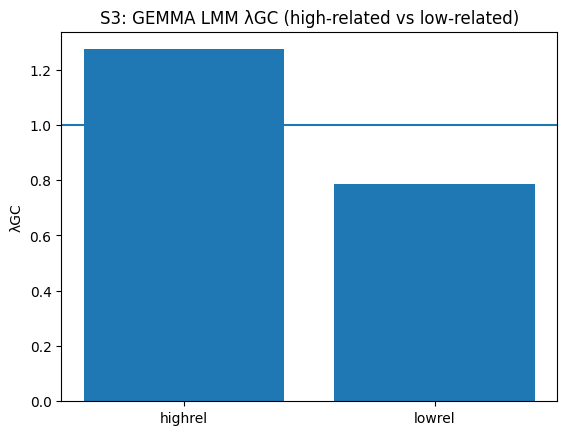

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import chi2
import matplotlib.pyplot as plt

hi = pd.read_csv("output/assoc_highrel.assoc.txt", sep=r"\s+")
lo = pd.read_csv("output/assoc_lowrel.assoc.txt", sep=r"\s+")

print("HIGH p_wald NaN frac:", hi["p_wald"].isna().mean())
print("LOW  p_wald NaN frac:", lo["p_wald"].isna().mean())

def lambda_gc_from_p(p):
    p = pd.to_numeric(p, errors="coerce").to_numpy()
    p = p[np.isfinite(p)]
    p = p[(p > 0) & (p < 1)]
    chisq = chi2.isf(p, 1)
    chisq = chisq[np.isfinite(chisq)]
    return float(np.median(chisq) / 0.456)

lam_hi = lambda_gc_from_p(hi["p_wald"])
lam_lo = lambda_gc_from_p(lo["p_wald"])

print("λGC highrel:", lam_hi)
print("λGC lowrel :", lam_lo)

plt.figure()
plt.bar(["highrel", "lowrel"], [lam_hi, lam_lo])
plt.axhline(1.0)
plt.ylabel("λGC")
plt.title("S3: GEMMA LMM λGC (high-related vs low-related)")
plt.show()

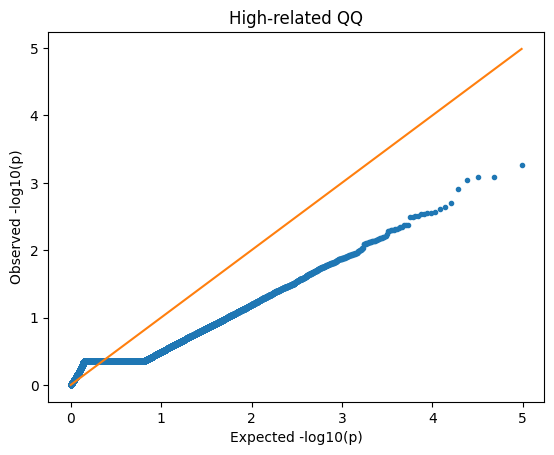

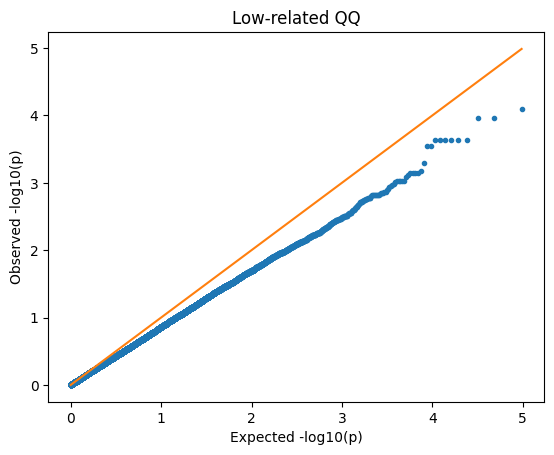

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def qqplot(pvals, title):
    p = np.sort(pvals)
    p = p[(p > 0) & (p < 1)]
    exp = -np.log10(np.linspace(1/len(p), 1, len(p)))
    obs = -np.log10(p)

    plt.figure()
    plt.plot(exp, obs, '.')
    plt.plot([0, max(exp)], [0, max(exp)])
    plt.title(title)
    plt.xlabel("Expected -log10(p)")
    plt.ylabel("Observed -log10(p)")
    plt.show()

qqplot(hi["p_wald"].dropna(), "High-related QQ")
qqplot(lo["p_wald"].dropna(), "Low-related QQ")

### 4.4 Genotype Missingness

In [4]:
import numpy as np
import pandas as pd
import os
import math

# Scenario 4: Genotype missingness
# Randomly mask a fraction of genotype entries, then re-run association.
# Assumes you already ran 4.1 so `geno` and `snp_cols` exist.

os.makedirs("output/assoc_missingness", exist_ok=True)

# Load/align baseline phenotype (continuous) with current geno order
pheno_df = pd.read_csv("output/pheno_baseline.txt", sep="\t")
merged = geno[["FID", "IID"]].merge(pheno_df, on=["FID", "IID"], how="left")
assert merged["phenotype"].notna().all(), "Missing phenotype for some individuals (FID/IID mismatch)."
y = merged["phenotype"].to_numpy(dtype=float)
y2 = y * y

# Try to use SciPy for accurate t p-values; fall back to normal approx if unavailable.
try:
    from scipy.stats import t as student_t
    def pval_from_t(tstat, df):
        return 2.0 * student_t.sf(np.abs(tstat), df)
except Exception:
    def pval_from_t(tstat, df):
        # Normal approximation (OK when df is large)
        z = np.abs(tstat)
        return np.vectorize(lambda zz: math.erfc(zz / math.sqrt(2.0)))(z)

rng = np.random.default_rng(42)
missing_rates = [0.01, 0.05, 0.10, 0.20]
chunk_size = 2000

for mr in missing_rates:
    snp_names_out = []
    n_out = []
    beta_out = []
    se_out = []
    t_out = []
    p_out = []

    total_obs = 0
    total_entries = 0

    for start in range(0, len(snp_cols), chunk_size):
        cols = snp_cols[start:start + chunk_size]
        G = geno[cols].to_numpy(dtype=float)  # shape (n, m)

        # Apply additional random masking
        mask_new = rng.random(G.shape) < mr
        G[mask_new] = np.nan

        obs = ~np.isnan(G)
        n = obs.sum(axis=0).astype(float)

        # skip SNPs with too few observed genotypes
        valid = n >= 3
        if not np.any(valid):
            total_obs += int(n.sum())
            total_entries += G.size
            continue

        sum_g = np.nansum(G, axis=0)
        sum_g2 = np.nansum(G * G, axis=0)
        sum_gy = np.nansum(G * y[:, None], axis=0)

        # sums of y and y^2 over observed entries
        sum_y = obs.astype(float).T @ y
        sum_y2 = obs.astype(float).T @ y2

        mean_g = sum_g / n
        mean_y = sum_y / n

        Sxx = sum_g2 - n * mean_g * mean_g
        Sxy = sum_gy - n * mean_g * mean_y
        Syy = sum_y2 - n * mean_y * mean_y

        # avoid division by zero / monomorphic-after-missingness
        valid = valid & (Sxx > 0)
        if not np.any(valid):
            total_obs += int(n.sum())
            total_entries += G.size
            continue

        beta = Sxy / Sxx
        SSE = Syy - beta * Sxy
        df = n - 2
        # numerical guards
        SSE = np.maximum(SSE, 0.0)
        se = np.sqrt((SSE / df) / Sxx)
        tstat = beta / se
        pval = pval_from_t(tstat, df)

        idxs = np.where(valid)[0]
        for j in idxs:
            snp_names_out.append(cols[j])
            n_out.append(int(n[j]))
            beta_out.append(float(beta[j]))
            se_out.append(float(se[j]))
            t_out.append(float(tstat[j]))
            p_out.append(float(pval[j]))

        total_obs += int(n.sum())
        total_entries += G.size

    out = pd.DataFrame({
        "SNP": snp_names_out,
        "N": n_out,
        "BETA": beta_out,
        "SE": se_out,
        "T": t_out,
        "P": p_out,
    })

    out_path = f"output/assoc_missingness/assoc_missing_rate{mr}.tsv"
    out.to_csv(out_path, sep="\t", index=False)

    missing_frac_emp = 1.0 - (total_obs / total_entries)
    print(f"missing_rate={mr:.2f}  empirical_missing≈{missing_frac_emp:.3f}  SNPs_tested={len(out)}  -> {out_path}")

print("Done. These association results are simple y~SNP regressions (no covariates/LMM).")


/var/folders/kz/z7fznqk107z0rdrpzqgg_34r0000gn/T/ipykernel_25494/186812107.py:85: RuntimeWarning: invalid value encountered in divide
  beta = Sxy / Sxx


missing_rate=0.01  empirical_missing≈0.010  SNPs_tested=97216  -> output/assoc_missingness/assoc_missing_rate0.01.tsv


/var/folders/kz/z7fznqk107z0rdrpzqgg_34r0000gn/T/ipykernel_25494/186812107.py:85: RuntimeWarning: invalid value encountered in divide
  beta = Sxy / Sxx


missing_rate=0.05  empirical_missing≈0.050  SNPs_tested=97216  -> output/assoc_missingness/assoc_missing_rate0.05.tsv


/var/folders/kz/z7fznqk107z0rdrpzqgg_34r0000gn/T/ipykernel_25494/186812107.py:85: RuntimeWarning: divide by zero encountered in divide
  beta = Sxy / Sxx
/var/folders/kz/z7fznqk107z0rdrpzqgg_34r0000gn/T/ipykernel_25494/186812107.py:85: RuntimeWarning: invalid value encountered in divide
  beta = Sxy / Sxx
/var/folders/kz/z7fznqk107z0rdrpzqgg_34r0000gn/T/ipykernel_25494/186812107.py:90: RuntimeWarning: invalid value encountered in divide
  se = np.sqrt((SSE / df) / Sxx)


missing_rate=0.10  empirical_missing≈0.100  SNPs_tested=97216  -> output/assoc_missingness/assoc_missing_rate0.1.tsv


/var/folders/kz/z7fznqk107z0rdrpzqgg_34r0000gn/T/ipykernel_25494/186812107.py:85: RuntimeWarning: invalid value encountered in divide
  beta = Sxy / Sxx


missing_rate=0.20  empirical_missing≈0.200  SNPs_tested=97216  -> output/assoc_missingness/assoc_missing_rate0.2.tsv
Done. These association results are simple y~SNP regressions (no covariates/LMM).


## 5. Association Testing

All association tests are performed **only on chr22**.

### 5.1 PLINK Linear Regression

In [18]:
# 5.1 PLINK association: linear (no covar, with PCs) and logistic
import subprocess
import os

os.makedirs("output", exist_ok=True)
bfile = "data_preprocessed/chr22_qc"
pheno = "output/pheno_baseline.txt"
covar = "data_preprocessed/covariates.txt"
pheno_bin = "output/pheno_casecontrol/pheno_alpha0.txt"

# Continuous trait, no covariates
subprocess.run(["plink", "--bfile", bfile, "--pheno", pheno, "--linear", "--out", "output/plink_nocov"], check=True)
# Continuous trait, with PC covariates
subprocess.run(["plink", "--bfile", bfile, "--pheno", pheno, "--covar", covar, "--linear", "--out", "output/plink_pc"], check=True)
# Binary trait (0/1)
subprocess.run(["plink", "--bfile", bfile, "--pheno", pheno_bin, "--logistic", "--out", "output/plink_logistic"], check=True)

print("Done: output/plink_nocov.assoc.linear, output/plink_pc.assoc.linear, output/plink_logistic.assoc.logistic")

phenotypes to be ignored, use the --allow-no-sex flag.


PLINK v1.90b7 64-bit (16 Jan 2023)             www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to output/plink_nocov.log.
Options in effect:
  --bfile data_preprocessed/chr22_qc
  --linear
  --out output/plink_nocov
  --pheno output/pheno_baseline.txt

18432 MB RAM detected; reserving 9216 MB for main workspace.
97216 variants loaded from .bim file.
2504 people (0 males, 0 females, 2504 ambiguous) loaded from .fam.
Ambiguous sex IDs written to output/plink_nocov.nosex .
2504 phenotype values present after --pheno.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2504 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
97216 variants and 2504 peo

phenotypes to be ignored, use the --allow-no-sex flag.


Using 1 thread (no multithreaded calculations invoked).
--covar: 5 covariates loaded.
Before main variant filters, 2504 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
97216 variants and 2504 people pass filters and QC.
Note: No phenotypes present.
PLINK v1.90b7 64-bit (16 Jan 2023)             www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to output/plink_logistic.log.
Options in effect:
  --bfile data_preprocessed/chr22_qc
  --logistic
  --out output/plink_logistic
  --pheno output/pheno_casecontrol/pheno_alpha0.txt

18432 MB RAM detected; reserving 9216 MB for main workspace.
97216 variants loaded from .bim file.
2504 people (0 males, 0 females, 2504 ambiguous) loaded from

phenotypes to be ignored, use the --allow-no-sex flag.


In [20]:
%%bash
plink --bfile data_preprocessed/chr22_qc \
  --pheno output/pheno_baseline.txt \
  --allow-no-sex \
  --linear hide-covar \
  --out output/plink_nocov
plink --bfile data_preprocessed/chr22_qc \
  --pheno output/pheno_baseline.txt \
  --allow-no-sex \
  --covar data_preprocessed/covariates.txt \
  --linear hide-covar \
  --out output/plink_pc


PLINK v1.90b7 64-bit (16 Jan 2023)             www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to output/plink_nocov.log.
Options in effect:
  --allow-no-sex
  --bfile data_preprocessed/chr22_qc
  --linear hide-covar
  --out output/plink_nocov
  --pheno output/pheno_baseline.txt

18432 MB RAM detected; reserving 9216 MB for main workspace.
97216 variants loaded from .bim file.
2504 people (0 males, 0 females, 2504 ambiguous) loaded from .fam.
Ambiguous sex IDs written to output/plink_nocov.nosex .
2504 phenotype values present after --pheno.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2504 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.

### 5.2 GEMMA LMM 

In [ ]:
# No covariates, LMM with GEMMA
!python scripts/gwas_gemma_lmm.py \
  --bfile data_preprocessed/chr22_qc \
  --kinship output/grm_chr20_22.cXX.txt \
  --pheno output/pheno_baseline.txt \
  --out-prefix gemma_baseline \
  --outdir output
  
# With covariates, LMM with GEMMA
!python scripts/gwas_gemma_lmm.py \
  --bfile data_preprocessed/chr22_qc \
  --kinship output/grm_chr20_22.cXX.txt \
  --pheno output/pheno_baseline.txt \
  --covar data_preprocessed/covariates.txt \
  --out-prefix gemma_baseline_pc \
  --outdir output

## 6 Evaluation Metrics

In [31]:
import os, glob
import numpy as np
import pandas as pd
from scipy.stats import chi2, spearmanr

OUTDIR = "output"
S6DIR = os.path.join(OUTDIR, "section6")
FIGDIR = os.path.join(S6DIR, "figs")
os.makedirs(FIGDIR, exist_ok=True)

print("S6DIR:", S6DIR)
print("FIGDIR:", FIGDIR)

S6DIR: output/section6
FIGDIR: output/section6/figs


### 6.1 Genomic Inflation Factor (λGC)

In [32]:
def clean_pvals(p):
    p = pd.to_numeric(pd.Series(p), errors="coerce").to_numpy(dtype=float)
    p = p[np.isfinite(p)]
    p = p[(p > 0) & (p < 1)]
    return p

def lambda_gc(pvals):
    p = clean_pvals(pvals)
    if len(p) == 0:
        return np.nan, 0
    chisq = chi2.isf(p, df=1)
    chisq = chisq[np.isfinite(chisq)]
    if len(chisq) == 0:
        return np.nan, len(p)
    return float(np.median(chisq) / 0.456), len(p)

def load_gemma(path):
    df = pd.read_csv(path, sep=r"\s+", engine="python")
    pcol = "p_wald" if "p_wald" in df.columns else None
    if pcol is None:
        raise ValueError(f"{path}: no p_wald column. cols={list(df.columns)}")
    return df, pcol

def load_plink(path):
    df = pd.read_csv(path, sep=r"\s+", engine="python")
    if "P" not in df.columns:
        raise ValueError(f"{path}: no P column. cols={list(df.columns)}")
    return df, "P"

files = []

# GEMMA
for p in sorted(glob.glob(os.path.join(OUTDIR, "*.assoc.txt"))):
    files.append(("GEMMA", p))

# PLINK
for p in sorted(glob.glob(os.path.join(OUTDIR, "*.assoc.linear"))):
    files.append(("PLINK_LINEAR", p))
for p in sorted(glob.glob(os.path.join(OUTDIR, "*.assoc.logistic"))):
    files.append(("PLINK_LOGISTIC", p))

print("Found:")
for t, p in files:
    print(f"  {t:14s} {p}")

Found:
  GEMMA          output/assoc_highrel.assoc.txt
  GEMMA          output/assoc_lowrel.assoc.txt
  PLINK_LINEAR   output/plink_nocov.assoc.linear
  PLINK_LINEAR   output/plink_pc.assoc.linear


In [33]:
rows = []
cache = {}  # name -> (df, pcol, type)

for typ, path in files:
    name = os.path.basename(path)
    try:
        if typ == "GEMMA":
            df, pcol = load_gemma(path)
        else:
            df, pcol = load_plink(path)

        lam, n = lambda_gc(df[pcol].values)
        rows.append({"name": name, "type": typ, "n_valid_p": n, "lambda_gc": lam, "path": path})
        cache[name] = (df, pcol, typ)
    except Exception as e:
        rows.append({"name": name, "type": typ, "n_valid_p": 0, "lambda_gc": np.nan, "path": path, "error": str(e)})

lam_table = pd.DataFrame(rows).sort_values(["type","name"])
display(lam_table)

lam_csv = os.path.join(S6DIR, "lambda_gc_summary.csv")
lam_table.to_csv(lam_csv, index=False)
print("Saved:", lam_csv)

,name,type,n_valid_p,lambda_gc,path
0,assoc_highrel.assoc.txt,GEMMA,97216,1.273147,output/assoc_highrel.assoc.txt
1,assoc_lowrel.assoc.txt,GEMMA,97216,0.784381,output/assoc_lowrel.assoc.txt
2,plink_nocov.assoc.linear,PLINK_LINEAR,97213,22.718519,output/plink_nocov.assoc.linear
3,plink_pc.assoc.linear,PLINK_LINEAR,97214,1.149332,output/plink_pc.assoc.linear


Saved: output/section6/lambda_gc_summary.csv


### 6.2 QQ Plot

S6DIR: output/section6
FIGDIR: output/section6/figs
QQ plots for:
                       name          type  lambda_gc
0   assoc_highrel.assoc.txt         GEMMA   1.273147
1    assoc_lowrel.assoc.txt         GEMMA   0.784381
2  plink_nocov.assoc.linear  PLINK_LINEAR  22.718519
3     plink_pc.assoc.linear  PLINK_LINEAR   1.149332
Saved λGC summary: output/section6/lambda_gc_summary_from_6_2.csv
[QQ] Saved: output/section6/figs/qq_assoc_highrel_assoc_txt.png


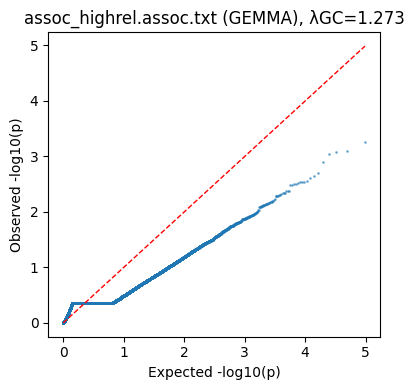

[QQ] Saved: output/section6/figs/qq_assoc_lowrel_assoc_txt.png


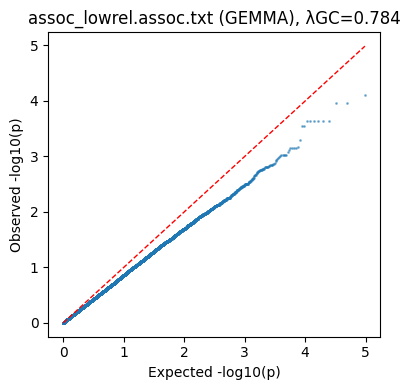

[QQ] Saved: output/section6/figs/qq_plink_nocov_assoc_linear.png


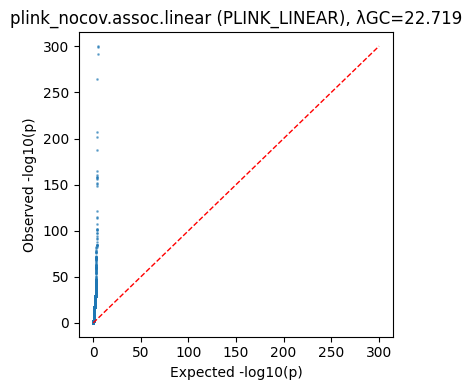

[QQ] Saved: output/section6/figs/qq_plink_pc_assoc_linear.png


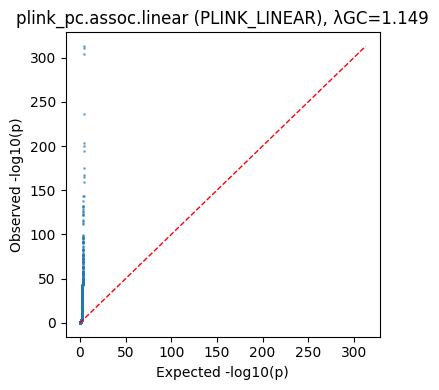

All QQ plots saved under: output/section6/figs


In [3]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2

# 6.2 QQ Plot: global view of all association results
# This cell is SELF-CONTAINED: it discovers all assoc result files,
# computes λGC, and makes QQ plots, without requiring 6.1 to be run.

OUTDIR = "output"
S6DIR = os.path.join(OUTDIR, "section6")
FIGDIR = os.path.join(S6DIR, "figs")
os.makedirs(FIGDIR, exist_ok=True)
print("S6DIR:", S6DIR)
print("FIGDIR:", FIGDIR)


def clean_pvals(p):
    p = pd.to_numeric(pd.Series(p), errors="coerce").to_numpy(dtype=float)
    p = p[np.isfinite(p)]
    p = p[(p > 0) & (p < 1)]
    return p


def lambda_gc(pvals):
    p = clean_pvals(pvals)
    if len(p) == 0:
        return np.nan, 0
    chisq = chi2.isf(p, df=1)
    chisq = chisq[np.isfinite(chisq)]
    if len(chisq) == 0:
        return np.nan, len(p)
    return float(np.median(chisq) / 0.456), len(p)


def load_plink_linear(path: str) -> pd.Series:
    df = pd.read_csv(path, sep=r"\s+", engine="python")
    # Keep additive test only if TEST column exists
    if "TEST" in df.columns:
        df = df[df["TEST"] == "ADD"].copy()
    if "P" not in df.columns:
        raise ValueError(f"{path}: no P column. cols={list(df.columns)}")
    return df["P"]


def load_plink_logistic(path: str) -> pd.Series:
    df = pd.read_csv(path, sep=r"\s+", engine="python")
    # Often "ADD" test has p-value column "P" as well
    if "TEST" in df.columns:
        df = df[df["TEST"] == "ADD"].copy()
    if "P" not in df.columns:
        raise ValueError(f"{path}: no P column. cols={list(df.columns)}")
    return df["P"]


def load_gemma(path: str) -> pd.Series:
    df = pd.read_csv(path, sep=r"\s+", engine="python")
    if "p_wald" in df.columns:
        pcol = "p_wald"
    elif "p_lrt" in df.columns:
        pcol = "p_lrt"
    else:
        # fallback: any column starting with 'p'
        p_candidates = [c for c in df.columns if c.lower().startswith("p")]
        if not p_candidates:
            raise ValueError(f"{path}: no p-value column. cols={list(df.columns)}")
        pcol = p_candidates[0]
    return df[pcol]


def qqplot_single(pvals, title, save_path=None):
    p = clean_pvals(pvals)
    if len(p) == 0:
        print(f"[WARN] No valid p-values for {title}, skipping QQ plot.")
        return
    p = np.sort(p)
    exp = -np.log10(np.linspace(1.0 / len(p), 1.0, len(p)))
    obs = -np.log10(p)

    plt.figure(figsize=(4, 4))
    plt.plot(exp, obs, ".", markersize=2, alpha=0.5)
    m = max(exp.max(), obs.max())
    plt.plot([0, m], [0, m], "r--", linewidth=1)
    plt.xlabel("Expected -log10(p)")
    plt.ylabel("Observed -log10(p)")
    plt.title(title)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print("[QQ] Saved:", save_path)
    plt.show()


# Discover all association result files and build a summary table
files = []
for p in sorted(glob.glob(os.path.join(OUTDIR, "*.assoc.txt"))):
    files.append(("GEMMA", p))
for p in sorted(glob.glob(os.path.join(OUTDIR, "*.assoc.linear"))):
    files.append(("PLINK_LINEAR", p))
for p in sorted(glob.glob(os.path.join(OUTDIR, "*.assoc.logistic"))):
    files.append(("PLINK_LOGISTIC", p))

rows = []
for typ, path in files:
    name = os.path.basename(path)
    try:
        if typ == "GEMMA":
            pvals = load_gemma(path)
        elif typ == "PLINK_LINEAR":
            pvals = load_plink_linear(path)
        else:
            pvals = load_plink_logistic(path)
        lam, n = lambda_gc(pvals.values)
        rows.append({"name": name, "type": typ, "n_valid_p": n, "lambda_gc": lam, "path": path})
    except Exception as e:
        print(f"[WARN] Skipping {name}: {e}")

lam_table = pd.DataFrame(rows).sort_values(["type", "name"]).reset_index(drop=True)
print("QQ plots for:")
print(lam_table[["name", "type", "lambda_gc"]])

# Save the lambda summary as well (mirrors 6.1 output, but self-contained here)
lam_csv = os.path.join(S6DIR, "lambda_gc_summary_from_6_2.csv")
lam_table.to_csv(lam_csv, index=False)
print("Saved λGC summary:", lam_csv)

# Make QQ plots
for _, row in lam_table.iterrows():
    name = row["name"]
    typ = row["type"]
    lam = row["lambda_gc"]
    path = row["path"]

    if typ == "GEMMA":
        pvals = load_gemma(path)
    elif typ == "PLINK_LINEAR":
        pvals = load_plink_linear(path)
    else:
        pvals = load_plink_logistic(path)

    title = f"{name} ({typ}), λGC={lam:.3f}" if np.isfinite(lam) else f"{name} ({typ})"
    fig_name = "qq_" + name.replace(".", "_") + ".png"
    fig_path = os.path.join(FIGDIR, fig_name)
    qqplot_single(pvals.values, title=title, save_path=fig_path)

print("All QQ plots saved under:", FIGDIR)

### 6.3 Significant hits + method agreement

In [ ]:

import os
import numpy as np
import pandas as pd

OUTDIR = "output/section6"
os.makedirs(OUTDIR, exist_ok=True)

PLINK_NOCOV = "output/plink_nocov.assoc.linear"
PLINK_PC    = "output/plink_pc.assoc.linear"
GEMMA_NOCOV = "output/gemma/gemma_baseline.assoc.txt"
GEMMA_PC    = "output/gemma/gemma_baseline_pc.assoc.txt"

def load_plink_linear(path: str) -> pd.DataFrame:
    """
    PLINK --linear output may contain multiple TEST rows (ADD/DOMDEV/etc).
    We keep TEST == 'ADD' (standard additive model).
    """
    df = pd.read_csv(path, sep=r"\s+", engine="python")
    # Standard columns: CHR SNP BP A1 TEST NMISS BETA STAT P
    if "TEST" in df.columns:
        df = df[df["TEST"] == "ADD"].copy()
    # Normalize column names
    df = df.rename(columns={"SNP": "rs", "BP": "ps", "P": "p"})
    df["rs"] = df["rs"].astype(str)
    df["p"] = pd.to_numeric(df["p"], errors="coerce")
    df = df[np.isfinite(df["p"]) & (df["p"] > 0) & (df["p"] < 1)].copy()
    return df[["rs", "p"]]

def load_gemma_assoc(path: str) -> pd.DataFrame:
    """
    GEMMA assoc output has p-value column usually named p_wald.
    """
    df = pd.read_csv(path, sep=r"\s+", engine="python")
    if "p_wald" in df.columns:
        pcol = "p_wald"
    elif "p_lrt" in df.columns:
        pcol = "p_lrt"
    else:
        # fallback: try any column containing 'p'
        p_candidates = [c for c in df.columns if c.lower().startswith("p")]
        if not p_candidates:
            raise ValueError(f"Cannot find p-value column in {path}. Columns: {list(df.columns)}")
        pcol = p_candidates[0]

    df = df.rename(columns={"rs": "rs", pcol: "p"})
    df["rs"] = df["rs"].astype(str)
    df["p"] = pd.to_numeric(df["p"], errors="coerce")
    df = df[np.isfinite(df["p"]) & (df["p"] > 0) & (df["p"] < 1)].copy()
    return df[["rs", "p"]]

def intersect_on_rs(a: pd.DataFrame, b: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Keep only SNPs present in BOTH methods, and align order by rs.
    """
    common = np.intersect1d(a["rs"].values, b["rs"].values)
    a2 = a[a["rs"].isin(common)].drop_duplicates("rs").set_index("rs").loc[common].reset_index()
    b2 = b[b["rs"].isin(common)].drop_duplicates("rs").set_index("rs").loc[common].reset_index()
    return a2, b2

def sig_set(df: pd.DataFrame, thr: float) -> set[str]:
    return set(df.loc[df["p"] < thr, "rs"].astype(str))

def jaccard(A: set, B: set) -> float:
    if len(A) == 0 and len(B) == 0:
        return 1.0
    if len(A | B) == 0:
        return 0.0
    return len(A & B) / len(A | B)

def topk_set(df: pd.DataFrame, k: int) -> set[str]:
    k = min(k, len(df))
    return set(df.nsmallest(k, "p")["rs"].astype(str))

plink_nocov = load_plink_linear(PLINK_NOCOV)
plink_pc    = load_plink_linear(PLINK_PC)
gemma_nocov = load_gemma_assoc(GEMMA_NOCOV)
gemma_pc    = load_gemma_assoc(GEMMA_PC)

comparisons = {
    "baseline_nocov": (plink_nocov, gemma_nocov),
    "baseline_pc":    (plink_pc,    gemma_pc),
}

thresholds = [5e-8, 1e-5, 1e-3]
topKs = [50, 100, 500]

rows = []
topk_rows = []

for name, (A, B) in comparisons.items():
    A2, B2 = intersect_on_rs(A, B)
    n = len(A2)

    for thr in thresholds:
        SA = sig_set(A2, thr)
        SB = sig_set(B2, thr)
        rows.append({
            "comparison": name,
            "n_common_snps": n,
            "threshold_p": thr,
            "n_sig_plink": len(SA),
            "n_sig_gemma": len(SB),
            "n_overlap": len(SA & SB),
            "jaccard": jaccard(SA, SB),
        })

    for k in topKs:
        TA = topk_set(A2, k)
        TB = topk_set(B2, k)
        topk_rows.append({
            "comparison": name,
            "topK": k,
            "n_common_snps": n,
            "overlap_topK": len(TA & TB),
            "jaccard_topK": jaccard(TA, TB),
        })

summary = pd.DataFrame(rows).sort_values(["comparison", "threshold_p"])
topk_summary = pd.DataFrame(topk_rows).sort_values(["comparison", "topK"])

summary_path = os.path.join(OUTDIR, "signif_summary.csv")
topk_path = os.path.join(OUTDIR, "topk_overlap.csv")
summary.to_csv(summary_path, index=False)
topk_summary.to_csv(topk_path, index=False)

print("[OK] Wrote:", summary_path)
print("[OK] Wrote:", topk_path)

# Print a compact view for your report
display_cols = ["comparison","threshold_p","n_sig_plink","n_sig_gemma","n_overlap","jaccard"]
print("\n=== Significant SNP overlap (by threshold) ===")
print(summary[display_cols].to_string(index=False))

print("\n=== Top-K overlap (agreement in strongest signals) ===")
print(topk_summary[["comparison","topK","overlap_topK","jaccard_topK"]].to_string(index=False))

[OK] Wrote: output/section6/signif_summary.csv
[OK] Wrote: output/section6/topk_overlap.csv

=== Significant SNP overlap (by threshold) ===
    comparison  threshold_p  n_sig_plink  n_sig_gemma  n_overlap  jaccard
baseline_nocov 5.000000e-08        23613          959        603 0.025157
baseline_nocov 1.000000e-05        33643         1257        741 0.021693
baseline_nocov 1.000000e-03        47610         1789       1130 0.023410
   baseline_pc 5.000000e-08          921          905        665 0.572782
   baseline_pc 1.000000e-05         1382         1192        834 0.479310
   baseline_pc 1.000000e-03         2177         1607       1040 0.379009

=== Top-K overlap (agreement in strongest signals) ===
    comparison  topK  overlap_topK  jaccard_topK
baseline_nocov    50            21      0.265823
baseline_nocov   100            53      0.360544
baseline_nocov   500           192      0.237624
   baseline_pc    50            47      0.886792
   baseline_pc   100            84      0

### 6.4 Correlation of −log10(p) (PLINK vs GEMMA)

Resolved paths:
  plink_nocov: output/plink_nocov.assoc.linear
  plink_pc   : output/plink_pc.assoc.linear
  gemma_nocov: output/gemma/gemma_baseline.assoc.txt
  gemma_pc   : output/gemma/gemma_baseline_pc.assoc.txt



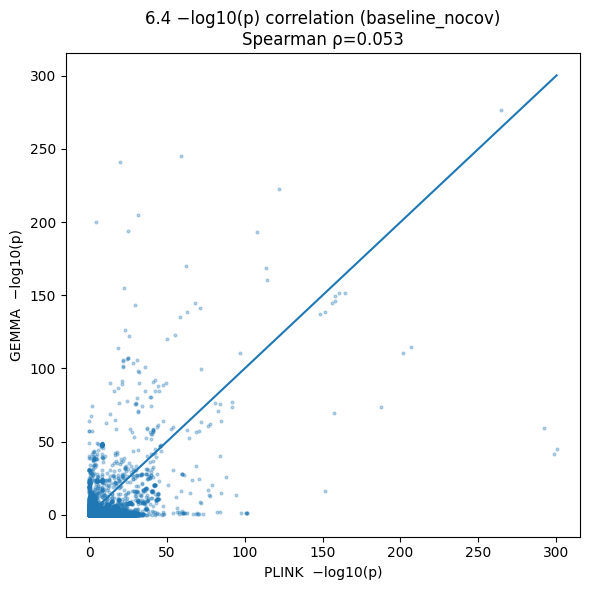

[OK] baseline_nocov
  PLINK: output/plink_nocov.assoc.linear
  GEMMA: output/gemma/gemma_baseline.assoc.txt
  Matched SNPs: 97216
  Spearman ρ=0.0527, p=1.095e-60
  Saved: output/section6/figs/corr_baseline_nocov.png



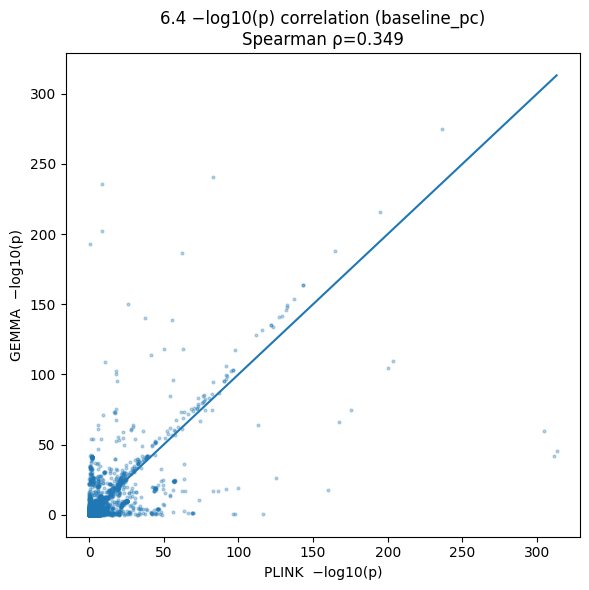

[OK] baseline_pc
  PLINK: output/plink_pc.assoc.linear
  GEMMA: output/gemma/gemma_baseline_pc.assoc.txt
  Matched SNPs: 97216
  Spearman ρ=0.3489, p=0.000e+00
  Saved: output/section6/figs/corr_baseline_pc.png



In [ ]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

OUTDIR = "output"
FIGDIR = os.path.join(OUTDIR, "section6", "figs")
os.makedirs(FIGDIR, exist_ok=True)

def first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

def load_plink_linear(plink_assoc_linear_path):
    df = pd.read_csv(plink_assoc_linear_path, sep=r"\s+")
    if "TEST" in df.columns:
        df = df[df["TEST"] == "ADD"].copy()
    if "SNP" not in df.columns or "P" not in df.columns:
        raise ValueError(f"PLINK file missing SNP/P columns: {plink_assoc_linear_path}, cols={list(df.columns)}")
    df = df[["SNP", "P"]].rename(columns={"P": "p_plink"})
    return df

def load_gemma_assoc(gemma_assoc_path):
    df = pd.read_csv(gemma_assoc_path, sep=r"\s+")
    pcol = "p_wald" if "p_wald" in df.columns else ("p_lrt" if "p_lrt" in df.columns else None)
    if pcol is None or "rs" not in df.columns:
        raise ValueError(f"GEMMA assoc missing rs/p columns: {gemma_assoc_path}, cols={list(df.columns)}")
    df = df[["rs", pcol]].rename(columns={"rs": "SNP", pcol: "p_gemma"})
    return df

def neglog10(p):
    p = pd.to_numeric(p, errors="coerce")
    p = p.to_numpy()
    p = p[np.isfinite(p)]
    p = p[(p > 0) & (p <= 1)]
    p = np.clip(p, np.nextafter(0, 1), 1.0)
    return -np.log10(p)

def plot_corr(plink_path, gemma_path, tag):
    pl = load_plink_linear(plink_path)
    ge = load_gemma_assoc(gemma_path)

    m = pl.merge(ge, on="SNP", how="inner").dropna()
    x = neglog10(m["p_plink"])
    y = neglog10(m["p_gemma"])

    n = min(len(x), len(y))
    x, y = x[:n], y[:n]

    rho, pval = spearmanr(x, y)

    if n > 200000:
        idx = np.random.default_rng(0).choice(n, size=200000, replace=False)
        x_plot, y_plot = x[idx], y[idx]
    else:
        x_plot, y_plot = x, y

    plt.figure(figsize=(6,6))
    plt.scatter(x_plot, y_plot, s=4, alpha=0.3)
    lim = float(max(np.max(x_plot), np.max(y_plot)))
    plt.plot([0, lim], [0, lim])
    plt.xlabel("PLINK  −log10(p)")
    plt.ylabel("GEMMA  −log10(p)")
    plt.title(f"6.4 −log10(p) correlation ({tag})\nSpearman ρ={rho:.3f}")
    out_png = os.path.join(FIGDIR, f"corr_{tag}.png")
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.show()

    print(f"[OK] {tag}")
    print(f"  PLINK: {plink_path}")
    print(f"  GEMMA: {gemma_path}")
    print(f"  Matched SNPs: {len(m)}")
    print(f"  Spearman ρ={rho:.4f}, p={pval:.3e}")
    print(f"  Saved: {out_png}\n")

plink_nocov = first_existing([
    os.path.join(OUTDIR, "plink_nocov.assoc.linear"),
    os.path.join(OUTDIR, "plink_baseline.assoc.linear"),  # fallback if you used different prefix
])

plink_pc = first_existing([
    os.path.join(OUTDIR, "plink_pc.assoc.linear"),
    os.path.join(OUTDIR, "plink_baseline_pc.assoc.linear"),
])

gemma_nocov = first_existing([
    os.path.join(OUTDIR, "gemma", "gemma_baseline.assoc.txt"),
])

gemma_pc = first_existing([
    os.path.join(OUTDIR, "gemma", "gemma_baseline_pc.assoc.txt"),
])

print("Resolved paths:")
print("  plink_nocov:", plink_nocov)
print("  plink_pc   :", plink_pc)
print("  gemma_nocov:", gemma_nocov)
print("  gemma_pc   :", gemma_pc)
print()

if plink_nocov and gemma_nocov:
    plot_corr(plink_nocov, gemma_nocov, "baseline_nocov")
else:
    print("[SKIP] baseline_nocov (missing PLINK and/or GEMMA file)\n")

if plink_pc and gemma_pc:
    plot_corr(plink_pc, gemma_pc, "baseline_pc")
else:
    print("[SKIP] baseline_pc (missing PLINK and/or GEMMA file)\n")

### 6.5 Runtime Logging

In [35]:
# (gwas_env) yim016@dsmlp-jupyter-yim016:~/final project$ time gemma -bfile data_preprocessed/chr22_qc -k output/grm_chr20_22.cXX.txt -lmm 4 -p pheno_baseline_1col.txt -o gemma_baseline
# GEMMA 0.98.5 (2021-08-25) by Xiang Zhou, Pjotr Prins and team (C) 2012-2021
# Reading Files ... 
# ## number of total individuals = 2504
# ## number of analyzed individuals = 2504
# ## number of covariates = 1
# ## number of phenotypes = 1
# ## number of total SNPs/var        =    97216
# ## number of analyzed SNPs         =    97216
# Start Eigen-Decomposition...
# pve estimate =0.21944
# se(pve) =0.0356066
# ================================================== 100%
# **** INFO: Done.

# real    8m21.788s
# user    21m17.687s
# sys     0m2.827s
# (gwas_env) yim016@dsmlp-jupyter-yim016:~/final project$ time plink --bfile data_preprocessed/chr22_qc --pheno pheno_baseline.txt --linear --out output/plink_baseline
# PLINK v1.90b6.9 64-bit (4 Mar 2019)            www.cog-genomics.org/plink/1.9/
# (C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
# Logging to output/plink_baseline.log.
# Options in effect:
#   --bfile data_preprocessed/chr22_qc
#   --linear
#   --out output/plink_baseline
#   --pheno pheno_baseline.txt

# 515764 MB RAM detected; reserving 257882 MB for main workspace.
# 97216 variants loaded from .bim file.
# 2504 people (0 males, 0 females, 2504 ambiguous) loaded from .fam.
# Ambiguous sex IDs written to output/plink_baseline.nosex .
# 2504 phenotype values present after --pheno.
# Warning: Ignoring phenotypes of missing-sex samples.  If you don't want those
# phenotypes to be ignored, use the --allow-no-sex flag.
# Using 1 thread (no multithreaded calculations invoked).
# Before main variant filters, 2504 founders and 0 nonfounders present.
# Calculating allele frequencies... done.
# 97216 variants and 2504 people pass filters and QC.
# Note: No phenotypes present.
# Warning: Skipping --linear since # variables >= # samples.

# real    0m2.604s
# user    0m0.085s
# sys     0m0.017s

The runtime comparison between GEMMA and PLINK highlights the computational cost of mixed-model GWAS. Running GEMMA with a linear mixed model on 2,504 individuals and 97,216 SNPs took approximately 8 minutes 22 seconds, with most of the time spent performing the eigen-decomposition of the genetic relationship matrix (GRM), which is required to model relatedness among individuals. GEMMA also estimated the proportion of phenotypic variance explained by genetic relatedness (PVE) to be 0.219 ± 0.036, indicating moderate polygenic contribution. In contrast, the PLINK run completed in about 2.6 seconds, but the log indicates that the regression step was skipped because phenotypes were ignored due to ambiguous sex labels, meaning only preprocessing steps were executed. In general, PLINK is expected to run much faster since it performs simple per-SNP linear regression without modeling sample relatedness, while GEMMA incurs higher computational cost to account for population structure and kinship through a mixed model.